# Business Understanding

## Problem
A drone delivery company wants to optimize their operations. They need to determine the best locations for depots to optimize delivery routes and costs. The company wants to analyze customers purchasing patterns to identify which product groups are often bought together.

## Datasets
- drone_cust_locations.csv
- drone_prod_groups.csv
## Goal
1. Use clustering algorithms to optimize depot locations.
2. Use frequent itemset mining and association rules to analyze purchasing patterns and identify which product groups are often bought together.

# Data Understanding

## Brief description of the datasets

- drone_cust_locations.csv: Contains locations of customers with id, x coordinate and y coordinate, when plotted into a 2D plane. 5956 entries and 3 columns.
- drone_prod_groups.csv: A value of 1 in prod1 to prod20 indicates that at least one product from the group was purchased, while a value of 0 indicates that no products from the group were purchased. 100000 entries and 21 columns.

Import libraries and load data

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

drone_locations = pd.read_csv('drone_cust_locations.csv', sep=';')
drone_groups = pd.read_csv('drone_prod_groups.csv')

Check the datasets

In [269]:
print("Drone Locations:")
print(drone_locations.head())
print(f"\nShape: {drone_locations.shape}")
print(f"\nInfo:")
print(drone_locations.info())

print("\n" * 5)

print("Drone Product Groups:")
print(drone_groups.head())
print(f"\nShape: {drone_groups.shape}")
print(f"\nInfo:")
print(drone_groups.info())

Drone Locations:
   clientid           x           y
0         1  622.771572  164.857623
1         2  416.357298  630.193634
2         3  292.735020  567.333231
3         4  737.211288  166.225676
4         5  540.475375  682.912298

Shape: (5956, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  5956 non-null   int64  
 1   x         5956 non-null   float64
 2   y         5956 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 139.7 KB
None






Drone Product Groups:
   ID  Prod1   Prod2   Prod3   Prod4   Prod5   Prod6   Prod7   Prod8   Prod9  \
0   1      0       0       0       0       0       0       0       0       1   
1   2      0       1       0       0       0       0       0       0       1   
2   3      0       0       0       0       0       0       1       0       0   
3   4      1       0       0       1

# Data Preparation

The datasets are checked for missing values, duplicates and basic statistics. The ID column is dropped from the product groups dataset as it is not needed for analysis.

Check locations data for missing values, duplicates and basic stats

In [270]:
print("Check missing values in drone_locations:")
print(drone_locations.isnull().sum())
print("\nStats:")
print(drone_locations.describe())

print(f"\nDuplicate client IDs: {drone_locations['clientid'].duplicated().sum()}")

Check missing values in drone_locations:
clientid    0
x           0
y           0
dtype: int64

Stats:
          clientid            x            y
count  5956.000000  5956.000000  5956.000000
mean   2978.500000   508.823177   427.554772
std    1719.493433   271.061462   289.044640
min       1.000000     0.017692     0.043285
25%    1489.750000   282.582920   170.079921
50%    2978.500000   518.100892   397.786441
75%    4467.250000   727.156497   669.982518
max    5956.000000   999.533215   999.731720

Duplicate client IDs: 0


check product groups data for missing values, duplicates and basic stats. Drop ID column

In [271]:
print("Check missing values in drone_groups:")
print(drone_groups.isnull().sum())
print("\nStats:")
print(drone_groups.describe())

drone_groups.drop(columns=['ID'], inplace=True)


Check missing values in drone_groups:
ID         0
Prod1      0
 Prod2     0
 Prod3     0
 Prod4     0
 Prod5     0
 Prod6     0
 Prod7     0
 Prod8     0
 Prod9     0
 Prod10    0
 Prod11    0
 Prod12    0
 Prod13    0
 Prod14    0
 Prod15    0
 Prod16    0
 Prod17    0
 Prod18    0
 Prod19    0
 Prod20    0
dtype: int64

Stats:
                  ID          Prod1         Prod2          Prod3  \
count  100000.000000  100000.000000  100000.00000  100000.000000   
mean    50000.500000       0.109980       0.13098       0.032710   
std     28867.657797       0.312866       0.33738       0.177877   
min         1.000000       0.000000       0.00000       0.000000   
25%     25000.750000       0.000000       0.00000       0.000000   
50%     50000.500000       0.000000       0.00000       0.000000   
75%     75000.250000       0.000000       0.00000       0.000000   
max    100000.000000       1.000000       1.00000       1.000000   

               Prod4          Prod5         Prod6      

Visualize client locations. There seems to be no customers diagonally across the plane possibly due to a highway, river or some other thing.

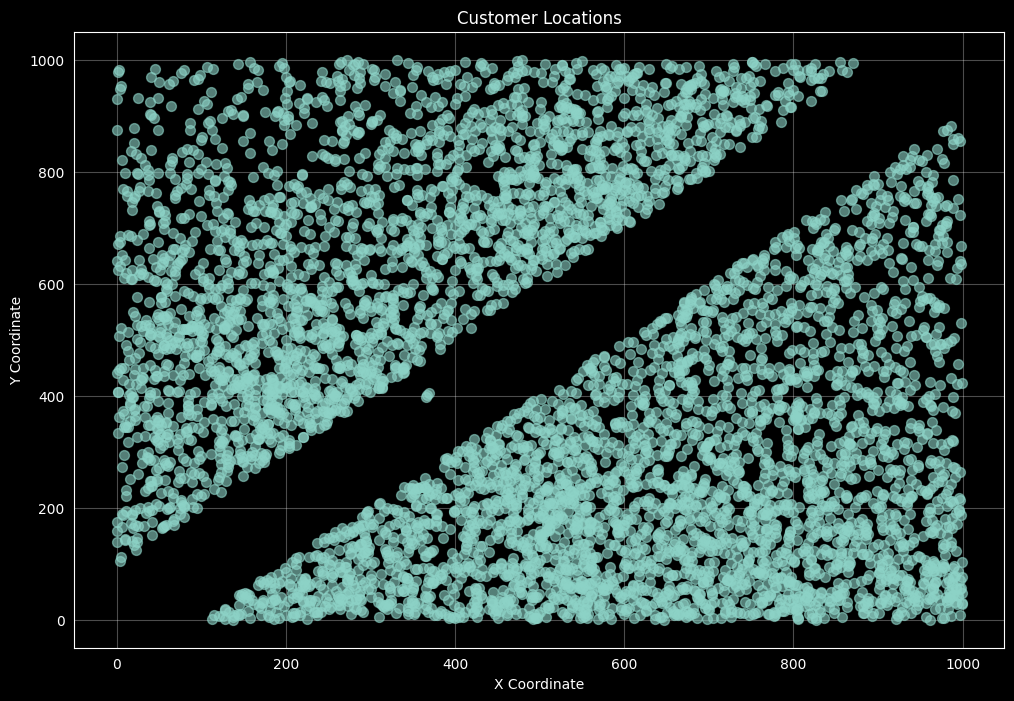

In [281]:
plt.figure(figsize=(12, 8))
plt.scatter(drone_locations['x'], drone_locations['y'], alpha=0.6, s=50)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Customer Locations')
plt.grid(True, alpha=0.3)
plt.show()

# Modeling

## Part 1: Clustering for depot location optimization

Depot locations are optimized using KMeans and Hierarchical Clustering.

Evaluation done with silhouette score. Inertia is calculated for KMeans also.

The number of depots can be adjusted by changing the n_depots variable.

## Part 2: Frequent itemset mining and association rules

Frequent itemsets are generated with apriori algorithm.

Association rules are generated with confidence threshold of 0.3 and sorted by confidence in descending order.



This cell determines the number of depots to use for KMeans and Hierachical Clustering. Change the value to test with different number of depots to see how it affects locations and metrics.

In [272]:
n_depots = 3


KMeans modeling

In [273]:

X = drone_locations[['x', 'y']].values

model = KMeans(init='random', n_clusters=n_depots, random_state=42)
drone_locations['depot'] = model.fit_predict(X)

depot_locations = model.cluster_centers_
silhouette = silhouette_score(X, drone_locations['depot'])
inertia = model.inertia_
print(f"Number of depots: {n_depots}")
print(f"Silhouette score: {silhouette:.4f}")
print(f"Inertia: {inertia:.2f}")
print(f"\nDepot locations:")
for i, (x, y) in enumerate(depot_locations):
    print(f"Depot {i}: ({x:.2f}, {y:.2f})")

Number of depots: 3
Silhouette score: 0.4221
Inertia: 328935427.52

Depot locations:
Depot 0: (702.08, 211.27)
Depot 1: (198.44, 383.26)
Depot 2: (548.21, 787.28)


Hierachical Clustering modeling

In [274]:
hierarchical = AgglomerativeClustering(n_clusters=n_depots, linkage='ward')
drone_locations['depot_hierarchical'] = hierarchical.fit_predict(X)

depot_locations_hier = np.array([X[drone_locations['depot_hierarchical'] == i].mean(axis=0)
                                 for i in range(n_depots)])

silhouette_hier = silhouette_score(X, drone_locations['depot_hierarchical'])

print(f"Number of depots: {n_depots}")
print(f"Silhouette score: {silhouette_hier:.4f}")
print(f"\nDepot locations:")
for i, (x, y) in enumerate(depot_locations_hier):
    print(f"Depot {i}: ({x:.2f}, {y:.2f})")

Number of depots: 3
Silhouette score: 0.4055

Depot locations:
Depot 0: (607.74, 151.23)
Depot 1: (709.98, 687.40)
Depot 2: (218.18, 578.47)


Check first 10 customers with assigned depots from KMeans and Hierarchical Clustering

In [275]:
print("First 10 customers with assigned depots:")
print(drone_locations[:10])

First 10 customers with assigned depots:
   clientid           x           y  depot  depot_hierarchical
0         1  622.771572  164.857623      0                   0
1         2  416.357298  630.193634      2                   2
2         3  292.735020  567.333231      1                   2
3         4  737.211288  166.225676      0                   0
4         5  540.475375  682.912298      2                   1
5         6  535.469492  318.439661      0                   0
6         7  640.380050  870.833221      2                   1
7         8  235.772075  359.048203      1                   2
8         9  481.896884  661.491838      2                   2
9        10  730.032789  312.177817      0                   0


Frequent itemset mining and association rules

In [276]:
drone_groups_bool = drone_groups.astype(bool)

min_support = 0.1
frequent_itemsets = apriori(drone_groups_bool, min_support=min_support, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.10998,(Prod1)
1,0.13098,( Prod2)
2,0.10459,( Prod5)
3,0.13499,( Prod7)
4,0.16179,( Prod8)
5,0.19853,( Prod9)
6,0.10848,( Prod11)
7,0.15971,( Prod12)
8,0.14557,( Prod14)
9,0.11880,( Prod15)


Rules generation with confidence threshold of 0.3. Rules are sorted by confidence in descending order.

In [277]:
min_confidence = 0.3

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

rules = rules.sort_values(by='confidence', ascending=False)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,( Prod15),( Prod9),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
3,( Prod20),( Prod19),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
2,( Prod19),( Prod20),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
1,( Prod9),( Prod15),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


Sort rules by lift with threshold of 2

In [278]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=2)

rules = rules.sort_values(by='lift', ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,( Prod15),( Prod9),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
1,( Prod9),( Prod15),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754
2,( Prod19),( Prod20),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
3,( Prod20),( Prod19),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007


# Evaluation

## Part 1: Clustering for depot location optimization

### Comparison: KMeans vs Hierarchical Clustering

#### KMeans with n_depots = 3:

- Silhouette score: 0.4221
- Inertia: 328935427.52

Depot locations:

- Depot 0: (702.08, 211.27)
- Depot 1: (198.44, 383.26)
- Depot 2: (548.21, 787.28)

#### Hierarchical Clustering with n_depots = 3:

- Silhouette score: 0.4055

Depot locations:
- Depot 0: (607.74, 151.23)
- Depot 1: (709.98, 687.40)
- Depot 2: (218.18, 578.47)

#### KMeans n_depots = 10:
- Silhouette score: 0.3663
- Inertia: 87600920.58

Depot locations:

- Depot 0: (881.10, 635.22)
- Depot 1: (452.08, 767.46)
- Depot 2: (732.74, 401.80)
- Depot 3: (308.10, 87.32)
- Depot 4: (849.63, 128.41)
- Depot 5: (648.69, 895.59)
- Depot 6: (107.45, 365.00)
- Depot 7: (152.51, 800.00)
- Depot 8: (547.02, 171.37)
- Depot 9: (250.11, 534.30)

#### Hierarchical Clustering n_depots = 10:

- Silhouette score: 0.3405

Depot locations:

- Depot 0: (338.33, 590.55)
- Depot 1: (381.06, 86.93)
- Depot 2: (115.99, 651.60)
- Depot 3: (820.72, 130.54)
- Depot 4: (591.93, 863.84)
- Depot 5: (121.83, 346.10)
- Depot 6: (566.65, 255.56)
- Depot 7: (778.17, 461.79)
- Depot 8: (257.28, 896.24)
- Depot 9: (887.26, 679.08)

### Analysis

KMeans generally performed better than Hierarchical Clustering. Silhouette scores were higher for KMeans in both cases.

Inertia is only for KMeans and it decreased when increasing number of depots.

Clustering quality is higher with 3 depots compared to 10 depots.

Computation time is slightly higher for Hierarchical Clustering, and increasing number of depots increases computation time for both algorithms.

KMeans creates more regular and compact clusters. Hierarchical Clustering creates more irregular and uneven clusters.

KMeans is more suitable for this problem due to better performance and more regular clusters.

## Part 2: Frequent itemset mining and association rules

Number of frequent itemsets: 16

Number of association rules found: 4

Association Rules:

1. {Prod15} → {Prod9} with support of 0.11, confidence of 0.94 and Lift of 4.7
2. {Prod20} → {Prod19} with support of 0.13, confidence of 0.91 and lift of 4.4
3. {Prod19} → {Prod20} with support of 0.13, confidence of 0.65, and lift of 4.4
4. {Prod9} → {Prod15} with support of 0.11, confidence of 0.56 and lift of 4.7

There are two obvious pairings of product groups that are often bought together. Groups 15 and 9, and groups 20 and 19. These pairs have high confidence and lift values, meaning that customers who buy from one of these groups are very likely to also buy from the other group in the pair.

Plot KMeans depot locations. Customers are colored based on their assigned depot, and depot locations are marked with red X.

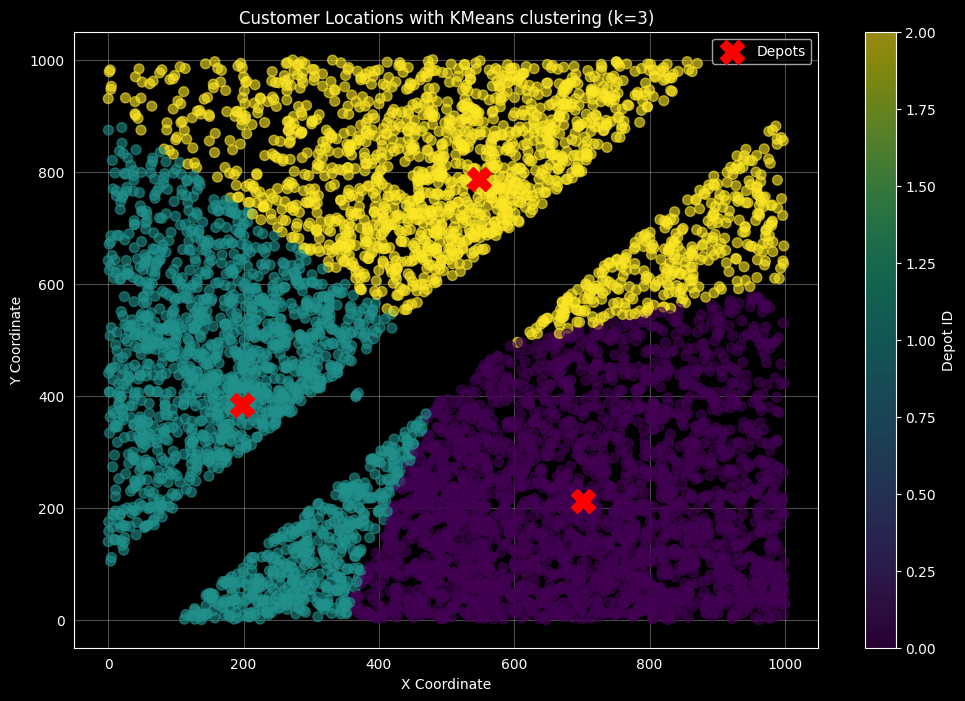

In [279]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(drone_locations['x'], drone_locations['y'], c=drone_locations['depot'], cmap='viridis' ,alpha=0.6, s=50)
plt.scatter(depot_locations[:, 0], depot_locations[:, 1], c='red', marker='X', s=300, label='Depots')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Customer Locations with KMeans clustering (k={n_depots})')
plt.colorbar(scatter, label='Depot ID')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Hierarchical Clustering done the same way as KMeans

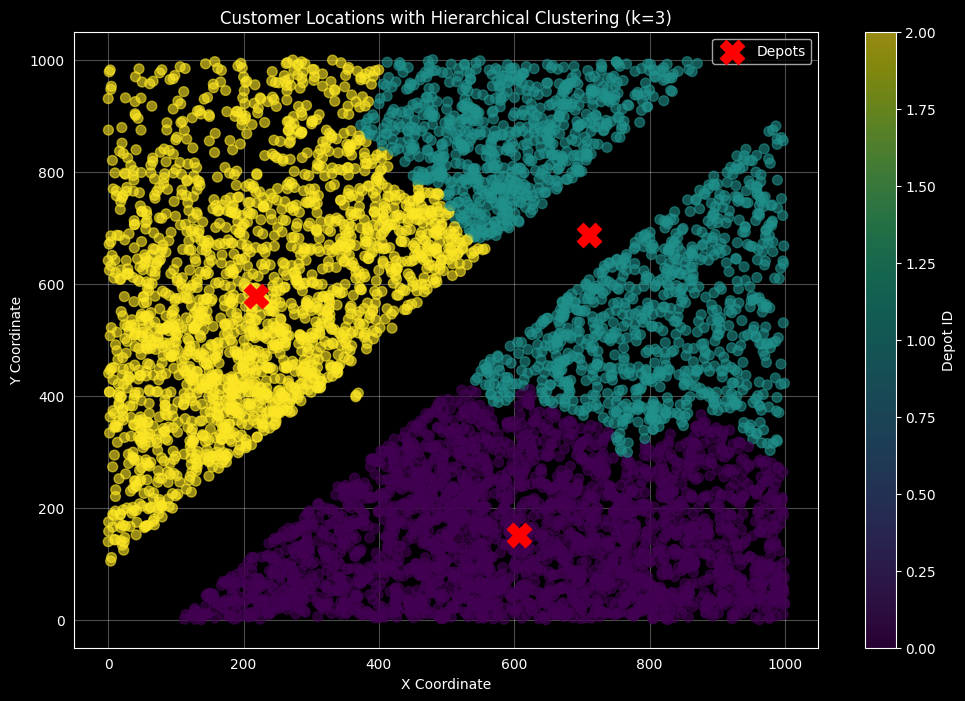

In [280]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(drone_locations['x'], drone_locations['y'],
                     c=drone_locations['depot_hierarchical'], cmap='viridis', alpha=0.6, s=50)
plt.scatter(depot_locations_hier[:, 0], depot_locations_hier[:, 1],
           c='red', marker='X', s=300, label='Depots')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Customer Locations with Hierarchical Clustering (k={n_depots})')
plt.colorbar(scatter, label='Depot ID')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Deployment

### Depot Placement
USe KMeans clustering for depot placement.

KMeans provides better silhouette scores and more balanced clusters.

3 depots provide better quality clusters, but more depots can be added for better local coverage if needed.

### Product recommendations

Bundle product groups 15 and 9 together (94% confidence, 4.7x lift), and also bundle groups 20 and 19 together (91% confidence, 4.4x lift) in marketing. Discounts, recommendations etc.